In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm  import tqdm
import json
import ast
import numpy as np
import gemmi
from mlindex.dataset_generation.EntryHelpers import spacegroup_to_symmetry 
from mlindex.utilities.Reindexing import reindex_entry_monoclinic
from mlindex.utilities.Reindexing import reindex_entry_orthorhombic
from mlindex.utilities.Reindexing import reindex_entry_triclinic
from mlindex.utilities.Reindexing import hexagonal_to_rhombohedral_unit_cell

from parse_opxrd import pick_peaks
from parse_opxrd import get_symmetry
from parse_opxrd import get_q_lattice

In [2]:
root = '/global/cfs/cdirs/m4064/dwmoreau/opxrd'

In [5]:
def parse_file(file_name):
    df = pd.read_json(file_name)
    data = json.loads(df['label'][0])
    phases = data['phases']
    if len(phases) > 0:
        phase = json.loads(data['phases'][0])
        spacegroup_number = phase['spacegroup']
        if spacegroup_number:
            spacegroup = gemmi.SpaceGroup(spacegroup_number).hm
        else:
            spacegroup = None
        unit_cell_entry = np.array(ast.literal_eval(phase['lattice']))
        unit_cell_entry[3:] *= np.pi/180
    else:
        spacegroup_number = None
        spacegroup = None
        unit_cell_entry = None
        unit_cell = None
    xray_info = json.loads(data.get("xray_info") or "{}")

    if spacegroup is None and unit_cell_entry is None:
        crystal_system = None
        bravais_lattice = None
        lattice_system = None
    elif spacegroup is None:
        unit_cell, crystal_system = get_symmetry(unit_cell_entry)
        crystal_system = crystal_system.lower()
        lattice_system = crystal_system
        if crystal_system == 'triclinic':
            bravais_lattice = 'aP'
        elif crystal_system == 'monoclinic':
            bravais_lattice = 'mP'
        elif crystal_system == 'orthorhombic':
            bravais_lattice = 'oP'
        elif crystal_system == 'tetragonal':
            bravais_lattice = 'tP'
        elif crystal_system == 'cubic':
            bravais_lattice = 'cP'
        elif crystal_system == 'hexagonal':
            bravais_lattice = 'hP'
        elif crystal_system == 'rhombohedral':
            bravais_lattice = 'hR'
        else:
            print(crystal_system)
            assert False
    else:
        bravais_lattice, crystal_family, crystal_system, lattice_system = spacegroup_to_symmetry(int(spacegroup_number))
        if lattice_system == 'triclinic':
            bravais_lattice = 'aP'
            unit_cell, _ = reindex_entry_triclinic(unit_cell_entry, space='direct')
        elif lattice_system == 'monoclinic':
            unit_cell = np.array(unit_cell_entry)
            unit_cell, spacegroup, _ = reindex_entry_monoclinic(
                np.array(unit_cell),
                spacegroup,
                space='direct'
            )
        elif lattice_system == 'orthorhombic':
            spacegroup, _, unit_cell, _ = reindex_entry_orthorhombic(
                np.array(unit_cell_entry),
                spacegroup,
                int(spacegroup_number)
                )
        elif lattice_system == 'rhombohedral':
            if np.all(unit_cell_entry[3:] == [np.pi/2, np.pi/2, 2*np.pi/3]):
                unit_cell, _ = hexagonal_to_rhombohedral_unit_cell(unit_cell_entry)
            else:
                unit_cell = unit_cell_entry
        else:
            unit_cell = unit_cell_entry
    info =  {
        "file_name": file_name,
        "primary_wavelength": float(xray_info["primary_wavelength"]) if xray_info.get("primary_wavelength") else None,
        "secondary_wavelength": float(xray_info["secondary_wavelength"]) if xray_info.get("secondary_wavelength") else None,
        "spacegroup": spacegroup,
        "unit_cell": unit_cell,
        "unit_cell_entry": unit_cell_entry,
        "theta2": df['two_theta_values'],
        "I": df['intensities'],
        "q": None,
    }
    valid = info["I"] > 0
    info["I"] = np.array(info["I"][valid])
    info["theta2"] = np.array(info["theta2"][valid])
    if info['primary_wavelength']:
        info['q'] = 2 * np.sin(np.pi/180 * info['theta2']/2) / info['primary_wavelength']

    info['bravais_lattice'] = bravais_lattice
    info['lattice_system'] = lattice_system
    return info

def plot(info, q_found=None, q_lattice=None):
    fig, axes = plt.subplots(1, 1, figsize=(15, 4))
    axes.plot(info['q'], info['I'])
    ylims = axes.get_ylim()
    if not q_found is None and len(q_found) > 0:
        for q in q_found:
            axes.plot([q, q], ylims, color=[0, 0, 0])
        axes.set_xlim([axes.get_xlim()[0], q_found[-1]])
    if not q_lattice is None:
        for q in q_lattice:
            axes.plot([q, q], [ylims[0], 0.5*ylims[1]], color=[1, 0, 0])
    axes.set_ylim(ylims)
    plt.show()

source = 'INT'
snr_threshold=10
min_relative_height=0.03

#source = 'CNRS'
#snr_threshold=6
#min_relative_height=0.015


file_names = sorted(os.listdir(root + '/' + source))
output_data = []
all_lattices = []
for file_name in tqdm(file_names):
    if file_name.endswith('.json'):
        info = parse_file(root + '/' + source + '/' + file_name)
        #print(root + '/' + source + '/' + file_name)
        #print(info['primary_wavelength'], info['secondary_wavelength'])
        #print(info['unit_cell'], info['spacegroup'])
        #print()
        all_lattices.append(info['unit_cell_entry'])
        if not info['q'] is None:
            try:
                peaks, bg, diag = pick_peaks(
                    info['q'], info['I'],
                    snr_threshold=snr_threshold,
                    min_relative_height=min_relative_height,
                    profile="pseudo_voigt",
                    bg_width=None,
                    bg_iterations=20,
                    smooth_window=10,  
                    merge_distance_factor=4,
                    show_diagnostics=False,
                )
                q_found = np.array([p['center'] for p in peaks])
                sigma_found = np.array([p['sigma'] for p in peaks])
                q_lattice = None
                if info['unit_cell']:
                    try:
                        q_lattice = get_q_lattice(info)
                    except:
                        pass
                if len(q_found) >= 20:
                    info['peak_positions'] = q_found
                    info['peak_sigmas'] = sigma_found
                    info['file_name'] = root + '/' + source + '/' + file_name
                    output_data.append(info)
                    #plot(info, q_found, q_lattice)  
                #plot(info)
            except:
                print('FAIL')
np.save(f'{source}_lattices.npy', np.array(all_lattices))
output_data = pd.DataFrame(output_data)
output_data.to_json(f'{source}_output_data.json')

 33%|███▎      | 6530/19796 [45:53<17:04, 12.94it/s]    

FAIL


 68%|██████▊   | 13511/19796 [2:15:05<20:00,  5.24it/s]   

FAIL


 81%|████████  | 16072/19796 [2:40:59<26:17,  2.36it/s]   

...

 86%|████████▋ | 17092/19796 [2:53:12<06:01,  7.48it/s]   

FAIL
FAIL


 88%|████████▊ | 17351/19796 [2:55:04<01:34, 25.96it/s]  

FAIL


100%|██████████| 19796/19796 [3:14:50<00:00,  1.69it/s]  


In [38]:
coeffs_q = []
coeffs_q2 = []
for index in range(len(output_data)):
    entry = output_data.iloc[index]
    slope_q, intercept_q = np.polyfit(entry.peak_positions, entry.peak_sigmas, 1)
    slope_q2, intercept_q2 = np.polyfit(entry.peak_positions**2, 2*entry.peak_positions*entry.peak_sigmas, 1)
    coeffs_q.append([slope_q, intercept_q])
    coeffs_q2.append([slope_q2, intercept_q2])
coeffs_q = np.stack(coeffs_q, axis=0)
coeffs_q2 = np.stack(coeffs_q2, axis=0)
q2_peak = []
sigma_q2_peak = []
for index in range(len(output_data.peak_positions)):
    q2_peak.append(output_data.peak_positions[index]**2)
    sigma_q2_peak.append(2*output_data.peak_positions[index]*output_data.peak_sigmas[index])
q2_peak = np.concatenate(q2_peak)
sigma_q2_peak = np.concatenate(sigma_q2_peak)
q_peak = np.concatenate([q for q in output_data.peak_positions])
sigma_peak = np.concatenate([s for s in output_data.peak_sigmas])

0.004214357211965508 0.0003369691297946984


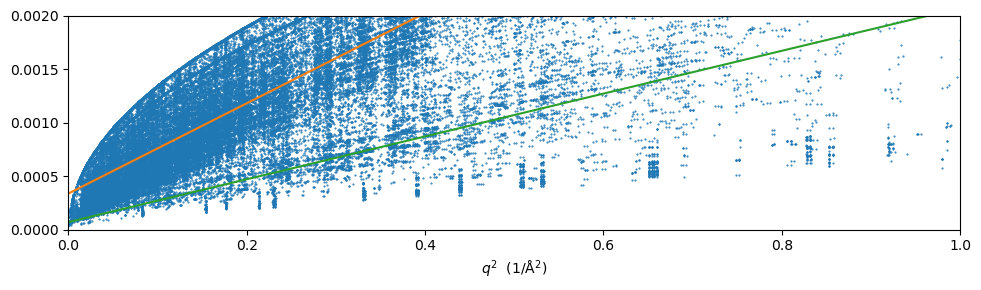

In [47]:
slope_q2, intercept_q2 = np.median(coeffs_q2, axis=0)
print(slope_q2, intercept_q2)
slope_q2_smsfx, intercept_q2_smsfx = 0.002, 0.00007
x_fit = np.array([0, 2])
y_fit = slope_q2 * x_fit + intercept_q2
y_fit_smsfx = slope_q2_smsfx * x_fit + intercept_q2_smsfx

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
axes.plot(q2_peak, sigma_q2_peak, marker='.', linestyle='none', markersize=1, alpha=1)
axes.plot(x_fit, y_fit)
axes.plot(x_fit, y_fit_smsfx)
#axes.set_yscale('log')
axes.set_ylim([0, 0.002])
axes.set_xlim([0, 1])
axes.set_xlabel(r'$q^2$  $(1/\mathrm{\AA}^2)$')
#axes.set_ylabel('
fig.tight_layout()
plt.show()

0.000894945341702509 0.0007884186950382115


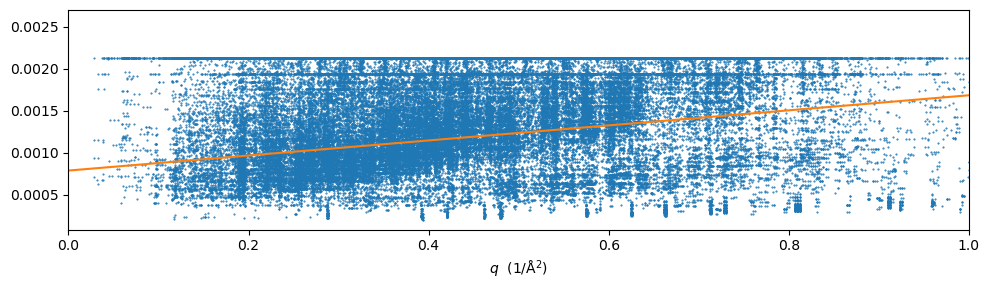

In [40]:
slope, intercept = np.median(coeffs_q, axis=0)
print(slope, intercept)
x_fit = np.array([0, 2])
y_fit = slope * x_fit + intercept

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
axes.plot(q_peak, sigma_peak, marker='.', linestyle='none', markersize=1, alpha=1)
axes.plot(x_fit, y_fit)
#axes.set_yscale('log')
#axes.set_ylim([0, 0.001])
axes.set_xlim([0, 1])
axes.set_xlabel(r'$q$  $(1/\mathrm{\AA}^2)$')
#axes.set_ylabel('
fig.tight_layout()
plt.show()